## Part 1: Install & Import

In [1]:
%pip install scikit-learn pandas numpy matplotlib seaborn

In [2]:
import os
import json
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Part 2: Mount Google Drive & Konfigurasi Path

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive'
PROJECT_DIR = os.path.join(BASE_DIR, 'Penalaran Komputer (460, 464)')

# Input dari Tahap 2
PATH_CSV    = os.path.join(PROJECT_DIR, 'Data', 'processed', 'cases.csv')

# Output Tahap 3
PATH_EVAL   = os.path.join(PROJECT_DIR, 'Data', 'eval')
PATH_RESULTS= os.path.join(PROJECT_DIR, 'Data', 'results')
LOG_PATH    = os.path.join(PROJECT_DIR, 'logs', 'retrieval.log')

for p in [PATH_EVAL, PATH_RESULTS, os.path.dirname(LOG_PATH)]:
    os.makedirs(p, exist_ok=True)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(LOG_PATH, mode='w', encoding='utf-8'),
        logging.StreamHandler()
    ],
    force=True
)

print(f"CSV Input  : {PATH_CSV}")
print(f"Eval Output: {PATH_EVAL}")
print(f"Results    : {PATH_RESULTS}")

Mounted at /content/drive
CSV Input  : /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/processed/cases.csv
Eval Output: /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval
Results    : /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/results


## Part 3: Load Data dari CSV (Output Tahap 2)

In [4]:
df = pd.read_csv(PATH_CSV)
print(f"Total kasus dimuat: {len(df)}")
print(f"Kolom tersedia   : {list(df.columns)}")
df.head(3)

Total kasus dimuat: 50
Kolom tersedia   : ['case_id', 'nomor_perkara', 'tahun_putusan', 'bulan_putusan', 'tanggal_putusan', 'jenis_perkara', 'tingkat_pemeriksaan', 'lembaga_peradilan', 'pasal', 'hakim_ketua', 'ringkasan_fakta', 'jumlah_kata_putusan', 'full_text']


,case_id,nomor_perkara,tahun_putusan,bulan_putusan,tanggal_putusan,jenis_perkara,tingkat_pemeriksaan,lembaga_peradilan,pasal,hakim_ketua,ringkasan_fakta,jumlah_kata_putusan,full_text
0,case_005,NaN,2012.0,November,9.0,Pidana Khusus HAM,Pertama,Pengadilan Negeri,pasal 44 ayat 3,hendri sumardi s h m h,dan memutus perkara perkara pidana pada pengad...,10076,p u t u s a nnomor 43 pid sus 2013 pn rhl demi...
1,case_006,603 pid sus 2013,2013.0,August,5.0,Pidana Khusus HAM,Banding,Pengadilan Negeri,pasal 44 ayat 1,hakim tersebut,perkara perkara pidana dengan acara biasa pada...,4474,putusan nomor 603 pid sus 2013 pn rhl demi kea...
2,case_007,NaN,2015.0,July,3.0,Pidana Khusus HAM,Banding,Pengadilan Negeri,pasal 310 ayat 4,NaN,NaN,3158,menimbang bahwa terdakwa diajukan di persidang...


In [5]:
df['text_feature'] = df['full_text'].fillna('') + ' ' + df['ringkasan_fakta'].fillna('')
df['text_feature'] = df['text_feature'].str.strip()

# Label untuk klasifikasi: pasal (sebagai proxy kategori putusan)
# Kita buat label sederhana dari pasal yang paling umum
df['label'] = df['pasal'].fillna('tidak diketahui')

# Simplifikasi label: ambil pasal pertama saja
def simplify_label(pasal):
    if pd.isna(pasal) or pasal == '':
        return 'tidak diketahui'
    # Ambil angka pasal pertama sebagai label
    import re
    match = re.search(r'pasal\s*(\d+)', str(pasal), re.IGNORECASE)
    if match:
        return f"pasal_{match.group(1)}"
    return 'lainnya'

df['label_simplified'] = df['pasal'].apply(simplify_label)

print("Distribusi label:")
print(df['label_simplified'].value_counts())
print(f"\nTotal dokumen dengan teks valid: {df['text_feature'].str.len().gt(50).sum()}")

Distribusi label:
label_simplified
pasal_44           19
pasal_81            5
pasal_116           4
pasal_6             4
pasal_34            4
pasal_193           2
pasal_4             2
pasal_49            2
pasal_310           1
pasal_23            1
pasal_5             1
pasal_114           1
pasal_46            1
pasal_385           1
tidak diketahui     1
pasal_71            1
Name: count, dtype: int64

Total dokumen dengan teks valid: 50


## Part 4: TF-IDF Vectorization

In [6]:
# 1. Pembuatan Matrix TF-IDF
tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

texts = df['text_feature'].tolist()
case_ids = df['case_id'].tolist()

# Fit dan transform semua dokumen
tfidf_matrix = tfidf.fit_transform(texts)

print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"   → {tfidf_matrix.shape[0]} dokumen x {tfidf_matrix.shape[1]} fitur")
logging.info(f"TF-IDF matrix built: {tfidf_matrix.shape}")


# 2. Fungsi retrieve() Berbasis Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity
import json

def retrieve(query: str, k: int = 5):
    """
    Fungsi wajib CBR untuk mencari kasus terdahulu yang paling mirip dengan kueri baru.
    """
    # 1. Bersihkan kueri teks (samakan formatnya menjadi lower case)
    query_clean = str(query).lower()

    # 2. Ubah teks kueri baru menjadi vektor TF-IDF menggunakan objek 'tfidf' kamu
    query_vector = tfidf.transform([query_clean])

    # 3. Hitung tingkat kemiripan (Cosine Similarity) kueri dengan seluruh database (tfidf_matrix)
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # 4. Ambil top-k indeks dengan nilai kemiripan tertinggi
    top_k_indices = similarities.argsort()[-k:][::-1]

    # 5. Bungkus hasilnya ke dalam list of dictionary
    results = []
    for idx in top_k_indices:
        # Ambil nilai nomor perkara, jika NaN ganti jadi strip "-" atau string kosong
        no_perkara = df.iloc[idx].get('nomor_perkara', '-')
        if pd.isna(no_perkara):
            no_perkara = "-"

        results.append({
            'case_id': df.iloc[idx]['case_id'],
            'nomor_perkara': no_perkara,
            'similarity_score': round(similarities[idx], 4)
        })
    return results


# 3. Uji Coba Manual (Demo Fungsi)
print("\n=== Uji Coba Fungsi Retrieval ===")
contoh_kueri = "Terdakwa terbukti menyalahgunakan narkotika golongan I jenis sabu secara bersama-sama"
hasil_uji = retrieve(contoh_kueri, k=3)
print(json.dumps(hasil_uji, indent=2))

2026-06-27 05:52:45,994 - INFO - TF-IDF matrix built: (50, 19291)


TF-IDF Matrix shape: (50, 19291)
   → 50 dokumen x 19291 fitur

=== Uji Coba Fungsi Retrieval ===
[
  {
    "case_id": "case_047",
    "nomor_perkara": "-",
    "similarity_score": 0.0478
  },
  {
    "case_id": "case_017",
    "nomor_perkara": "-",
    "similarity_score": 0.042
  },
  {
    "case_id": "case_046",
    "nomor_perkara": "-",
    "similarity_score": 0.0373
  }
]


## Part 5: Train-Test Split (80:20)

In [7]:
# Encode label
le = LabelEncoder()
labels_encoded = le.fit_transform(df['label_simplified'])

# Split indeks untuk mempertahankan mapping ke case_id
indices = np.arange(len(df))
idx_train, idx_test = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)

X_train = tfidf_matrix[idx_train]
X_test  = tfidf_matrix[idx_test]
y_train = labels_encoded[idx_train]
y_test  = labels_encoded[idx_test]

case_ids_train = [case_ids[i] for i in idx_train]
case_ids_test  = [case_ids[i] for i in idx_test]

print(f"Train set : {X_train.shape[0]} dokumen")
print(f"Test set  : {X_test.shape[0]} dokumen")
print(f"Label kelas: {list(le.classes_)}")
logging.info(f"Split done: {X_train.shape[0]} train, {X_test.shape[0]} test")

2026-06-27 05:52:46,025 - INFO - Split done: 40 train, 10 test


Train set : 40 dokumen
Test set  : 10 dokumen
Label kelas: ['pasal_114', 'pasal_116', 'pasal_193', 'pasal_23', 'pasal_310', 'pasal_34', 'pasal_385', 'pasal_4', 'pasal_44', 'pasal_46', 'pasal_49', 'pasal_5', 'pasal_6', 'pasal_71', 'pasal_81', 'tidak diketahui']


## Part 6: SVM Classifier untuk Case Retrieval

In [8]:
# Train SVM dengan kernel linear (cocok untuk teks TF-IDF)
svm_model = SVC(
    kernel='linear',
    C=1.0,
    probability=True,  # Aktifkan probability untuk confidence score
    random_state=42
)

svm_model.fit(X_train, y_train)
print("SVM model berhasil ditraining.")
logging.info("SVM training complete.")

2026-06-27 05:52:47,016 - INFO - SVM training complete.


SVM model berhasil ditraining.


## Part 7: Fungsi Retrieval (Cosine Similarity)

In [9]:
from typing import List, Dict

def retrieve(query: str, k: int = 5) -> List[Dict]:
    """
    Retrieve top-k kasus paling mirip dengan query.

    Args:
        query: teks kasus baru (deskripsi fakta/dakwaan)
        k: jumlah kasus yang dikembalikan

    Returns:
        List of dict berisi case_id, similarity_score, pasal, ringkasan_fakta
    """
    # 1. Pre-process & vectorize query
    query_vec = tfidf.transform([query])

    # 2. Hitung cosine similarity dengan SEMUA dokumen di case base
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # 3. Ambil top-k indeks dengan similarity tertinggi
    top_k_indices = np.argsort(sim_scores)[::-1][:k]

    # 4. Susun hasil
    results = []
    for idx in top_k_indices:
        row = df.iloc[idx]
        results.append({
            'case_id'         : row['case_id'],
            'similarity_score': round(float(sim_scores[idx]), 4),
            'nomor_perkara'   : row.get('nomor_perkara', ''),
            'tanggal_putusan' : row.get('tanggal_putusan', ''),
            'pasal'           : row.get('pasal', ''),
            'ringkasan_fakta' : str(row.get('ringkasan_fakta', ''))[:300],
        })

    logging.info(f"Retrieved top-{k} for query (len={len(query)}): {[r['case_id'] for r in results]}")
    return results


def retrieve_with_svm(query: str, k: int = 5) -> Dict:
    """
    Combine cosine similarity retrieval dengan SVM classification.
    SVM memprediksi kategori pasal dari query,
    lalu retrieval diprioritaskan dari kasus dengan label sama.
    """
    query_vec = tfidf.transform([query])

    # SVM prediction
    predicted_label_encoded = svm_model.predict(query_vec)[0]
    predicted_label = le.inverse_transform([predicted_label_encoded])[0]
    svm_proba = svm_model.predict_proba(query_vec)[0]
    confidence = round(float(max(svm_proba)), 4)

    # Cosine similarity retrieval
    top_k_cases = retrieve(query, k=k)

    return {
        'predicted_label': predicted_label,
        'confidence'     : confidence,
        'top_k_cases'    : top_k_cases
    }

print("Fungsi retrieve() dan retrieve_with_svm() siap digunakan.")

Fungsi retrieve() dan retrieve_with_svm() siap digunakan.


## Part 8: Pengujian Awal dengan Query Uji

In [10]:
# Siapkan 5-10 query uji beserta ground-truth case_id
# Query diambil dari ringkasan_fakta dokumen test set

eval_queries = []

for i, idx in enumerate(idx_test[:10]):  # Gunakan 10 kasus pertama dari test set
    row = df.iloc[idx]
    # Query: ambil 200 karakter pertama dari full_text sebagai simulasi kasus baru
    query_text = str(row['text_feature'])[:500]
    eval_queries.append({
        'query_id'         : f"query_{i+1:03d}",
        'query_text'       : query_text,
        'ground_truth_case': row['case_id'],
        'ground_truth_label': df.iloc[idx]['label_simplified']
    })

# Simpan queries ke JSON
queries_path = os.path.join(PATH_EVAL, 'queries.json')
with open(queries_path, 'w', encoding='utf-8') as f:
    json.dump(eval_queries, f, ensure_ascii=False, indent=2)

print(f"Disimpan {len(eval_queries)} query uji ke: {queries_path}")

# Demo retrieval untuk 1 query
print("\n=== Demo Retrieval ===\n")
demo_query = eval_queries[0]
print(f"Query ID    : {demo_query['query_id']}")
print(f"Ground Truth: {demo_query['ground_truth_case']} ({demo_query['ground_truth_label']})")
print(f"Query text  : {demo_query['query_text'][:200]}...\n")

results = retrieve_with_svm(demo_query['query_text'], k=5)
print(f"SVM Prediksi Label : {results['predicted_label']} (confidence: {results['confidence']:.2%})")
print("\nTop-5 Kasus Terdekat:")
for i, case in enumerate(results['top_k_cases'], 1):
    match = '✓' if case['case_id'] == demo_query['ground_truth_case'] else ' '
    print(f"  {match} {i}. {case['case_id']} | sim={case['similarity_score']:.4f} | pasal: {case['pasal'][:50]}")

2026-06-27 05:52:47,790 - INFO - Retrieved top-5 for query (len=500): ['case_014', 'case_026', 'case_032', 'case_025', 'case_030']


Disimpan 10 query uji ke: /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval/queries.json

=== Demo Retrieval ===

Query ID    : query_001
Ground Truth: case_014 (pasal_116)
Query text  : putusannomor 2803 pdt g 2025 pa tgrs demi keadilan berdasarkan ketuhanan yang maha esapengadilan agama tigaraksa yang memeriksa dan mengadili perkaratertentu pada tingkat pertama dalam persidangan maj...

SVM Prediksi Label : pasal_44 (confidence: 32.78%)

Top-5 Kasus Terdekat:
  ✓ 1. case_014 | sim=0.3022 | pasal: pasal 116, Kompilasi Hukum Islam
    2. case_026 | sim=0.2070 | pasal: pasal 49, 3 tahun 2006
    3. case_032 | sim=0.1472 | pasal: pasal 116 huruf f, Kompilasi Hukum Islam
    4. case_025 | sim=0.1074 | pasal: pasal 4 ayat 1, 18 tahun 2003
    5. case_030 | sim=0.1011 | pasal: pasal 116 huruf f, Kompilasi Hukum Islam


## Part 9: Evaluasi Model Retrieval

In [11]:
def eval_retrieval(queries: List[Dict], k: int = 5) -> Dict:
    """
    Evaluasi retrieval menggunakan Accuracy@k:
    Dianggap benar jika ground-truth case_id ada di top-k hasil retrieval.
    """
    hits = 0
    for q in queries:
        top_k = retrieve(q['query_text'], k=k)
        retrieved_ids = [r['case_id'] for r in top_k]
        if q['ground_truth_case'] in retrieved_ids:
            hits += 1

    accuracy_at_k = hits / len(queries) if queries else 0
    return {
        'total_queries': len(queries),
        'hits'         : hits,
        f'accuracy_at_{k}': round(accuracy_at_k, 4)
    }

# Evaluasi retrieval
retrieval_eval = eval_retrieval(eval_queries, k=5)
print("=== Hasil Evaluasi Retrieval ===")
for k, v in retrieval_eval.items():
    print(f"  {k}: {v}")
logging.info(f"Retrieval eval: {retrieval_eval}")

2026-06-27 05:52:47,817 - INFO - Retrieved top-5 for query (len=500): ['case_014', 'case_026', 'case_032', 'case_025', 'case_030']
2026-06-27 05:52:47,829 - INFO - Retrieved top-5 for query (len=500): ['case_045', 'case_040', 'case_034', 'case_038', 'case_018']
2026-06-27 05:52:47,839 - INFO - Retrieved top-5 for query (len=500): ['case_045', 'case_031', 'case_035', 'case_001', 'case_021']
2026-06-27 05:52:47,849 - INFO - Retrieved top-5 for query (len=500): ['case_045', 'case_046', 'case_039', 'case_043', 'case_049']
2026-06-27 05:52:47,859 - INFO - Retrieved top-5 for query (len=500): ['case_045', 'case_018', 'case_034', 'case_038', 'case_040']
2026-06-27 05:52:47,867 - INFO - Retrieved top-5 for query (len=500): ['case_045', 'case_049', 'case_039', 'case_024', 'case_011']
2026-06-27 05:52:47,875 - INFO - Retrieved top-5 for query (len=500): ['case_027', 'case_007', 'case_009', 'case_041', 'case_008']
2026-06-27 05:52:47,883 - INFO - Retrieved top-5 for query (len=500): ['case_026', 

=== Hasil Evaluasi Retrieval ===
  total_queries: 10
  hits: 10
  accuracy_at_5: 1.0


In [12]:
# Evaluasi SVM Classification (pada test set)
y_pred = svm_model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
present_classes = np.unique(np.concatenate([y_test, y_pred]))
target_names = [le.classes_[i] for i in present_classes]

print("=== Evaluasi SVM Classifier ===")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1-Score : {f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, labels=present_classes, target_names=target_names, zero_division=0))

logging.info(f"SVM eval — Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f}")

# Simpan metrik ke CSV
metrics_df = pd.DataFrame([{
    'model'    : 'TF-IDF + SVM',
    'accuracy' : round(acc, 4),
    'precision': round(prec, 4),
    'recall'   : round(rec, 4),
    'f1_score' : round(f1, 4),
    'retrieval_accuracy_at_5': 0
}])
metrics_path = os.path.join(PATH_EVAL, 'retrieval_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"\nMetrik disimpan ke: {metrics_path}")

2026-06-27 05:52:47,956 - INFO - SVM eval — Acc:0.5000 Prec:0.2500 Rec:0.5000 F1:0.3333


=== Evaluasi SVM Classifier ===
  Accuracy : 0.5000
  Precision: 0.2500
  Recall   : 0.5000
  F1-Score : 0.3333

Classification Report:
              precision    recall  f1-score   support

   pasal_116       0.50      1.00      0.67         1
    pasal_34       0.00      0.00      0.00         1
     pasal_4       0.00      0.00      0.00         1
    pasal_44       0.50      1.00      0.67         4
    pasal_49       0.00      0.00      0.00         1
     pasal_6       0.00      0.00      0.00         1
    pasal_81       0.00      0.00      0.00         1

    accuracy                           0.50        10
   macro avg       0.14      0.29      0.19        10
weighted avg       0.25      0.50      0.33        10


Metrik disimpan ke: /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval/retrieval_metrics.csv


## Part 10: Visualisasi Hasil

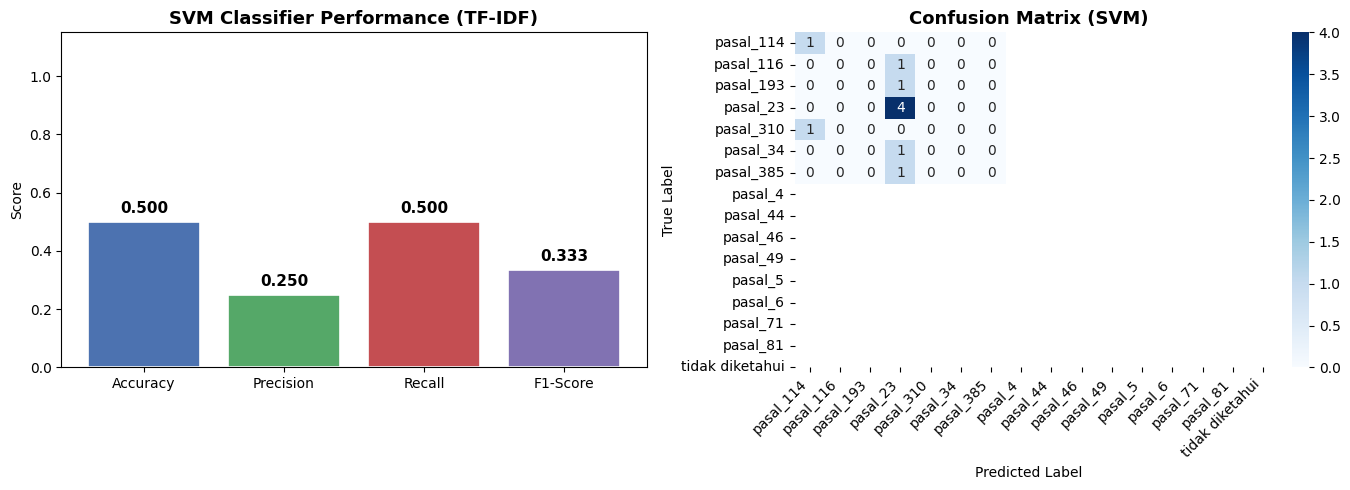

Plot disimpan ke: /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval/retrieval_performance.png


In [13]:
# Bar chart performa model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Metrik SVM
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [acc, prec, rec, f1]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars = axes[0].bar(metric_names, metric_values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('SVM Classifier Performance (TF-IDF)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
for bar, val in zip(bars, metric_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1])
axes[1].set_title('Confusion Matrix (SVM)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plot_path = os.path.join(PATH_EVAL, 'retrieval_performance.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot disimpan ke: {plot_path}")

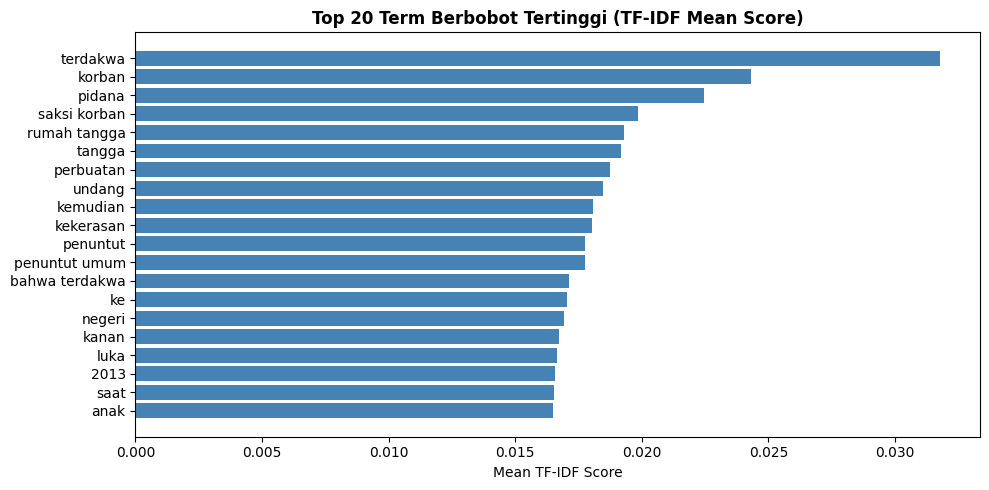

Plot disimpan ke: /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval/top_tfidf_terms.png


In [14]:
# Top 20 term paling penting berdasarkan TF-IDF
feature_names = tfidf.get_feature_names_out()
tfidf_scores  = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_20_idx    = tfidf_scores.argsort()[::-1][:20]

plt.figure(figsize=(10, 5))
plt.barh([feature_names[i] for i in top_20_idx[::-1]],
         [tfidf_scores[i] for i in top_20_idx[::-1]],
         color='steelblue')
plt.title('Top 20 Term Berbobot Tertinggi (TF-IDF Mean Score)', fontweight='bold')
plt.xlabel('Mean TF-IDF Score')
plt.tight_layout()
tfidf_plot_path = os.path.join(PATH_EVAL, 'top_tfidf_terms.png')
plt.savefig(tfidf_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot disimpan ke: {tfidf_plot_path}")

## Part 11: Error Analysis

In [15]:
# Analisis kasus yang salah diprediksi
error_analysis = []
for i, (true, pred) in enumerate(zip(y_test, y_pred)):
    if true != pred:
        case_id = case_ids_test[i]
        error_analysis.append({
            'case_id'        : case_id,
            'true_label'     : le.inverse_transform([true])[0],
            'predicted_label': le.inverse_transform([pred])[0],
            'ringkasan_fakta': str(df[df['case_id'] == case_id]['ringkasan_fakta'].values[0])[:200]
        })

if error_analysis:
    error_df = pd.DataFrame(error_analysis)
    print(f"Total kasus salah prediksi: {len(error_df)} dari {len(idx_test)} test kasus")
    print("\nDetail kasus gagal:")
    print(error_df[['case_id', 'true_label', 'predicted_label']].to_string(index=False))

    # Simpan error analysis
    error_path = os.path.join(PATH_EVAL, 'error_analysis.csv')
    error_df.to_csv(error_path, index=False, encoding='utf-8')
    print(f"\nError analysis disimpan ke: {error_path}")
else:
    print("Tidak ada kasus salah prediksi pada test set.")

print("\n=== Rekomendasi Perbaikan ===")
print("1. Tambah jumlah dokumen (>50) untuk distribusi label lebih merata")
print("2. Coba kernel RBF pada SVM untuk non-linear boundary")
print("3. Pertimbangkan IndoBERT embedding untuk representasi semantik lebih kaya")
print("4. Lakukan hyperparameter tuning (C, gamma) menggunakan GridSearchCV")
print("5. Tambahkan fitur metadata (tahun, pasal) sebagai tambahan fitur TF-IDF")

Total kasus salah prediksi: 5 dari 10 test kasus

Detail kasus gagal:
 case_id true_label predicted_label
case_046    pasal_4        pasal_44
case_018    pasal_6        pasal_44
case_027   pasal_81        pasal_44
case_026   pasal_49       pasal_116
case_020   pasal_34        pasal_44

Error analysis disimpan ke: /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval/error_analysis.csv

=== Rekomendasi Perbaikan ===
1. Tambah jumlah dokumen (>50) untuk distribusi label lebih merata
2. Coba kernel RBF pada SVM untuk non-linear boundary
3. Pertimbangkan IndoBERT embedding untuk representasi semantik lebih kaya
4. Lakukan hyperparameter tuning (C, gamma) menggunakan GridSearchCV
5. Tambahkan fitur metadata (tahun, pasal) sebagai tambahan fitur TF-IDF
